# 02 — Preprocessing: aggregation to a spatial grid

**What we do:** turn the ~33 000 individual epicentres into the modelling unit —
the **number of M>=4.0 events per 2x2 degree grid cell per year** — and run
exploratory data analysis on the result.

**Why:** the Bayesian models treat each *cell-year* as one Poisson count
observation. Aggregating to a regular grid (a) gives a well-defined count
variable, (b) defines the spatial units across which Model 2 will pool
information, and (c) makes the "rare cell vs busy cell" contrast explicit. This
maps to *Criterion 1 — Preprocessing.*

The grid and the Stan-input construction live in `utils/data_prep.py` so that
both models are fed identical data.

In [1]:
import sys, os, warnings
sys.path.append("..")            # make the utils package importable
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["figure.dpi"] = 110

from utils.display import display_df, display_image

In [2]:
from utils.data_prep import assign_cells, cell_center, LAT_BINS, LON_BINS

df = pd.read_csv("../data/raw/earthquakes_japan.csv")
df["year"] = df["time"].str[:4].astype(int)
print("Grid: lat bins", LAT_BINS, "\n      lon bins", LON_BINS)
print(f"Cell size: 2 deg x 2 deg  ->  up to {(len(LAT_BINS)-1)*(len(LON_BINS)-1)} cells")

Grid: lat bins [24 26 28 30 32 34 36 38 40 42 44 46 48 50] 
      lon bins [122 124 126 128 130 132 134 136 138 140 142 144 146 148 150 152 154]
Cell size: 2 deg x 2 deg  ->  up to 208 cells


### Step 1 — assign each event to a grid cell
`pd.cut` maps latitude/longitude to integer bin indices `(lat_idx, lon_idx)`,
combined into a string `cell_id`. Events outside the grid edges are dropped.

In [3]:
df = assign_cells(df)
print("Events kept after gridding:", len(df))
print("Distinct cells with >=1 event:", df["cell_id"].nunique())
display_df(df[["time","latitude","longitude","mag","lat_idx","lon_idx","cell_id"]],
           caption="Events with assigned grid cells")

Events kept after gridding: 33106
Distinct cells with >=1 event: 154


,time,latitude,longitude,mag,lat_idx,lon_idx,cell_id
0,2000-12-30T19:42:52.710Z,24.317000,122.974000,5.100000,0,0,0_0
1,2000-12-28T07:54:47.320Z,43.175000,147.770000,4.400000,9,12,9_12
2,2000-12-28T05:24:53.430Z,34.200000,139.108000,4.600000,5,8,5_8
3,2000-12-28T04:25:12.150Z,34.045000,139.160000,4.000000,5,8,5_8
4,2000-12-26T22:12:47.090Z,44.557000,148.173000,4.800000,10,13,10_13
5,2000-12-26T15:52:41.300Z,43.264000,143.992000,4.100000,9,10,9_10
6,2000-12-24T10:46:57.180Z,28.267000,142.914000,4.100000,2,10,2_10
7,2000-12-22T10:13:01.110Z,44.790000,147.196000,6.200000,10,12,10_12
8,2000-12-22T10:06:39.510Z,30.964000,141.745000,4.500000,3,9,3_9
9,2000-12-21T20:50:06.180Z,33.518000,140.497000,4.400000,4,9,4_9


... 33086 more rows (showing first 20 of 33106)


### Step 2 — annual counts per cell
Each `(cell_id, year)` pair becomes one observation with its event `count`. We
attach the cell-centre coordinates (for mapping) to build
`grid_annual_counts.csv`, and write a separate `grid_metadata.csv` with one row
per cell.

**Design choice — only observed cell-years are rows.** A cell-year with zero
recorded events almost always means "this ocean/inland cell is not seismically
active at M>=4", not "an active cell happened to be silent". Including a flood of
structural zeros would distort the Poisson means. We therefore model the
**154 cells that ever produced an event**, each over the years in which it was
active. (This is discussed again as a modelling assumption in notebook 04.)

In [4]:
annual = (df.groupby(["cell_id", "lat_idx", "lon_idx", "year"])
            .size().reset_index(name="count"))

# cell-centre coordinates
centers = annual.apply(lambda r: cell_center(int(r.lat_idx), int(r.lon_idx)),
                       axis=1, result_type="expand")
annual["lat_center"] = centers[0]
annual["lon_center"] = centers[1]
annual = annual[["cell_id","year","count","lat_idx","lon_idx","lat_center","lon_center"]]

metadata = (annual.groupby(["cell_id","lat_idx","lon_idx","lat_center","lon_center"])
                  .agg(n_years=("year","nunique"),
                       total_events=("count","sum"),
                       mean_count=("count","mean"))
                  .reset_index())

os.makedirs("../data/processed", exist_ok=True)
annual.to_csv("../data/processed/grid_annual_counts.csv", index=False)
metadata.to_csv("../data/processed/grid_metadata.csv", index=False)

print("grid_annual_counts:", annual.shape, " grid_metadata:", metadata.shape)
display_df(annual.sort_values("count", ascending=False),
           caption="grid_annual_counts.csv (sorted by count — Tohoku 2011 on top)")

grid_annual_counts: (2086, 7)  grid_metadata: (154, 8)


,cell_id,year,count,lat_idx,lon_idx,lat_center,lon_center
1481,6_10,2011,1403,6,10,37.000000,143.000000
1603,6_9,2011,1021,6,9,37.000000,141.000000
1628,7_10,2011,927,7,10,39.000000,143.000000
680,1_10,2010,568,1,10,27.000000,143.000000
1418,5_8,2000,536,5,8,35.000000,139.000000
1453,5_9,2011,439,5,9,35.000000,141.000000
483,11_15,2006,410,11,15,47.000000,153.000000
1499,6_11,2011,369,6,11,37.000000,145.000000
681,1_10,2011,280,1,10,27.000000,143.000000
1651,7_11,2011,265,7,11,39.000000,145.000000


... 2066 more rows (showing first 20 of 2086)


In [5]:
display_df(metadata.sort_values("total_events", ascending=False),
           caption="grid_metadata.csv (one row per cell, sorted by total events)")

,cell_id,lat_idx,lon_idx,lat_center,lon_center,n_years,total_events,mean_count
116,6_9,6,9,37.000000,141.000000,24,2882,120.083333
107,6_10,6,10,37.000000,143.000000,24,2304,96.000000
118,7_10,7,10,39.000000,143.000000,24,1949,81.208333
104,5_9,5,9,35.000000,141.000000,24,1675,69.791667
33,11_15,11,15,47.000000,153.000000,24,1411,58.791667
54,1_10,1,10,27.000000,143.000000,24,1223,50.958333
0,0_0,0,0,25.000000,123.000000,24,1195,49.791667
128,8_10,8,10,41.000000,143.000000,24,974,40.583333
103,5_8,5,8,35.000000,139.000000,24,849,35.375000
126,7_9,7,9,39.000000,141.000000,24,840,35.000000


... 134 more rows (showing first 20 of 154)


### EDA 1 — distribution of annual counts
The count distribution is extremely **right-skewed**: most cell-years have only
a handful of events, while a few (east-coast cells, especially in 2011) have
hundreds. The log-scale histogram makes the bulk visible. This skew, plus
counts being non-negative integers, is exactly why a **Poisson with a log link**
is the natural likelihood.

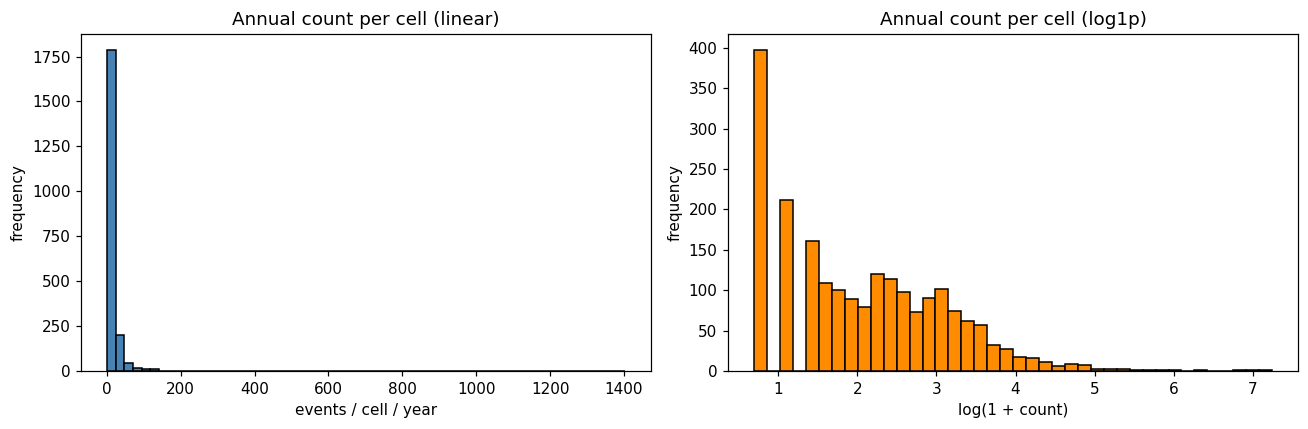

,count
count,2086.000000
mean,15.870566
std,52.866780
min,1.000000
25%,2.000000
50%,6.000000
75%,16.000000
max,1403.000000


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(annual["count"], bins=60, color="steelblue", edgecolor="k")
axes[0].set_title("Annual count per cell (linear)")
axes[0].set_xlabel("events / cell / year"); axes[0].set_ylabel("frequency")

axes[1].hist(np.log1p(annual["count"]), bins=40, color="darkorange", edgecolor="k")
axes[1].set_title("Annual count per cell (log1p)")
axes[1].set_xlabel("log(1 + count)"); axes[1].set_ylabel("frequency")
plt.tight_layout(); plt.show()

display_df(annual["count"].describe().to_frame("count"),
           caption="Summary of the annual-count response")

### EDA 2 — map of mean activity per cell
Average annual count per cell, drawn on the grid. The east-coast subduction
band is an order of magnitude more active than inland/western cells — the
spatial signal Model 2 will try to exploit.

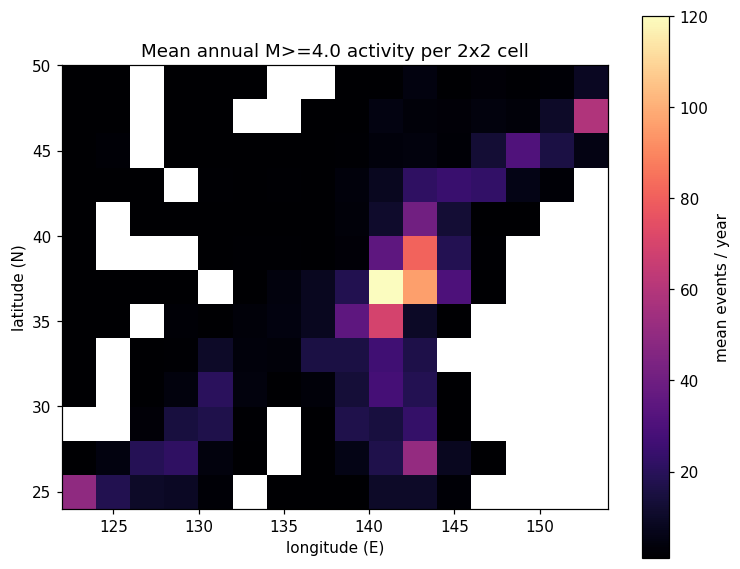

In [7]:
# build a lat_idx x lon_idx grid of mean counts for a heatmap
nlat, nlon = len(LAT_BINS)-1, len(LON_BINS)-1
grid = np.full((nlat, nlon), np.nan)
for _, r in metadata.iterrows():
    grid[int(r.lat_idx), int(r.lon_idx)] = r["mean_count"]

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(grid, origin="lower", cmap="magma",
               extent=[LON_BINS[0], LON_BINS[-1], LAT_BINS[0], LAT_BINS[-1]],
               aspect="equal")
cbar = plt.colorbar(im, ax=ax, shrink=0.8); cbar.set_label("mean events / year")
ax.set_xlabel("longitude (E)"); ax.set_ylabel("latitude (N)")
ax.set_title("Mean annual M>=4.0 activity per 2x2 cell")
plt.show()

## Summary
- Aggregation yields **{C} active cells** and **{N} cell-year observations**
  (numbers printed above).
- The response is heavily right-skewed with a long tail dominated by 2011 —
  motivating a Poisson/log-link model and foreshadowing the Tohoku outlier
  discussion.
- Strong east-west spatial gradient is the physical basis for the partial-
  pooling model.

Outputs written: `data/processed/grid_annual_counts.csv`,
`data/processed/grid_metadata.csv`. Next: `03_priors.ipynb`.